### Импорт библиотек

In [12]:
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

### Загрузка данных

In [13]:
SCENARIO = 'scen_3'

STOPS_PATH = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\stops.gpkg'      # жилые здания
ISOCHRONES_PATH  = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\isochrones_start.gpkg'    # 500-м изохроны
ROUTES_K_PATH = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\routes_kriterii.gpkg' # МАРШРУТЫ

In [14]:
stops = gpd.read_file(STOPS_PATH)
isochrones = gpd.read_file(ISOCHRONES_PATH)
routes = gpd.read_file(ROUTES_K_PATH)
sep = ','
print(f"Остановки:  {len(stops)} объектов")
print(f"Изохроны:   {len(isochrones)} объектов")
print(f"Маршруты:   {len(routes)} объектов")

Остановки:  551 объектов
Изохроны:   690 объектов
Маршруты:   40 объектов


In [15]:
# Ячейка 5 — Создаём таблицу «остановка ↔ маршрут» (one-to-many)

# Копируем нужные поля
stops_work = stops[['ya_stop_id', 'ya_line_id']].copy()

# Разбиваем строку на список
stops_work['line_list'] = (
    stops_work['ya_line_id']
    .astype(str)
    .str.split(sep)
)

# Разворачиваем список в отдельные строки
stops_exploded = stops_work.explode('line_list')

# Чистим пробелы и пустые значения
stops_exploded['line_id_clean'] = stops_exploded['line_list'].str.strip()
stops_exploded = stops_exploded[
    stops_exploded['line_id_clean'].notna() & 
    (stops_exploded['line_id_clean'] != '') &
    (stops_exploded['line_id_clean'] != 'nan')
]

# Итоговая таблица-связка
stop_to_route = stops_exploded[['ya_stop_id', 'line_id_clean']].rename(
    columns={'line_id_clean': 'ya_line_id'}
).drop_duplicates()

print(f"Уникальных маршрутов:  {stop_to_route['ya_line_id'].nunique()}")
print(f"Уникальных остановок:  {stop_to_route['ya_stop_id'].nunique()}")
print(f"Всего пар «остановка–маршрут»: {len(stop_to_route)}")
stop_to_route.head(10)

Уникальных маршрутов:  40
Уникальных остановок:  551
Всего пар «остановка–маршрут»: 1973


,ya_stop_id,ya_line_id
0,stop__9884354,2161483905
0,stop__9884354,2161483980
0,stop__9884354,2161483919
0,stop__9884354,2161483976
0,stop__9884354,2161483909
0,stop__9884354,2161483912
0,stop__9884354,2161483953
1,stop__9884378,2161483905
1,stop__9884378,2161483926
1,stop__9884378,3079437094


### Присоединение маршрутов к изохронам

In [16]:
# Приводим типы ключей к строке для надёжного join
isochrones['ya_stop_id'] = isochrones['ya_stop_id'].astype(str)
stop_to_route['ya_stop_id'] = stop_to_route['ya_stop_id'].astype(str)
stop_to_route['ya_line_id'] = stop_to_route['ya_line_id'].astype(str)

# Мержим: к каждой изохроне добавляем маршруты, проходящие через её остановку
iso_with_routes = isochrones.merge(
    stop_to_route,
    on='ya_stop_id',
    how='inner'
)

print(f"Строк после присоединения: {len(iso_with_routes)}")
print(f"Уникальных маршрутов с изохронами: {iso_with_routes['ya_line_id'].nunique()}")

Строк после присоединения: 1973
Уникальных маршрутов с изохронами: 40


### Агрегация изохрон по маршруту

In [17]:
# Для каждого ya_line_id объединяем все полигоны изохрон в один

route_isochrones = (
    iso_with_routes[['ya_line_id', 'geometry']]
    .dissolve(by='ya_line_id')
    .reset_index()
)

# Подсчитываем количество остановок в каждом маршруте для информации
stops_count = (
    stop_to_route
    .groupby('ya_line_id')['ya_stop_id']
    .nunique()
    .reset_index()
    .rename(columns={'ya_stop_id': 'stops_count'})
)

route_isochrones = route_isochrones.merge(stops_count, on='ya_line_id', how='left')

print(f"Итого маршрутов с агрегированными изохронами: {len(route_isochrones)}")
route_isochrones.head(10)

Итого маршрутов с агрегированными изохронами: 40


,ya_line_id,geometry,stops_count
0,10032,"POLYGON ((53.22191 56.8393, 53.22017 56.84033,...",32
1,2161483900,"POLYGON ((53.20287 56.83928, 53.20136 56.83992...",41
2,2161483903,"POLYGON ((53.12214 56.82903, 53.12213 56.82911...",65
3,2161483905,"MULTIPOLYGON (((53.16172 56.78904, 53.16144 56...",24
4,2161483909,"MULTIPOLYGON (((53.14314 56.80893, 53.14034 56...",24
5,2161483912,"MULTIPOLYGON (((53.15433 56.79856, 53.15412 56...",29
6,2161483913,"MULTIPOLYGON (((53.17101 56.86074, 53.171 56.8...",62
7,2161483914,"MULTIPOLYGON (((53.14974 56.82678, 53.14765 56...",34
8,2161483917,"MULTIPOLYGON (((53.20343 56.83922, 53.20309 56...",40
9,2161483919,"MULTIPOLYGON (((53.21513 56.79785, 53.21144 56...",33


In [18]:
# Ячейка 9 — Присоединяем информацию из маршрутов к итоговому слою

# Берём атрибуты из routes (например, название) — если они есть
route_attrs = routes.drop(columns='geometry').drop_duplicates(subset='ya_line_id')

route_isochrones_final = route_isochrones.merge(
    route_attrs[['ya_line_id','rank']],  # добавьте сюда нужные поля из routes
    on='ya_line_id',
    how='left'
)

print(f"Итоговый слой: {len(route_isochrones_final)} полигонов")
print(f"CRS: {route_isochrones_final.crs}")
route_isochrones_final.head()

Итоговый слой: 40 полигонов
CRS: EPSG:4326


,ya_line_id,geometry,stops_count,rank
0,10032,"POLYGON ((53.22191 56.8393, 53.22017 56.84033,...",32,1
1,2161483900,"POLYGON ((53.20287 56.83928, 53.20136 56.83992...",41,2
2,2161483903,"POLYGON ((53.12214 56.82903, 53.12213 56.82911...",65,3
3,2161483905,"MULTIPOLYGON (((53.16172 56.78904, 53.16144 56...",24,2
4,2161483909,"MULTIPOLYGON (((53.14314 56.80893, 53.14034 56...",24,3


### Сохранение результата

In [19]:
OUTPUT_PATH = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\isochrones_final.gpkg'
route_isochrones_final.to_file(OUTPUT_PATH, driver="GPKG", layer="route_isochrones")
print(f"Результат сохранён: {OUTPUT_PATH}")

Результат сохранён: X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\scen_3\isochrones_final.gpkg


In [20]:
route_isochrones_final

,ya_line_id,geometry,stops_count,rank
0,10032,"POLYGON ((53.22191 56.8393, 53.22017 56.84033,...",32,1
1,2161483900,"POLYGON ((53.20287 56.83928, 53.20136 56.83992...",41,2
2,2161483903,"POLYGON ((53.12214 56.82903, 53.12213 56.82911...",65,3
3,2161483905,"MULTIPOLYGON (((53.16172 56.78904, 53.16144 56...",24,2
4,2161483909,"MULTIPOLYGON (((53.14314 56.80893, 53.14034 56...",24,3
5,2161483912,"MULTIPOLYGON (((53.15433 56.79856, 53.15412 56...",29,3
6,2161483913,"MULTIPOLYGON (((53.17101 56.86074, 53.171 56.8...",62,3
7,2161483914,"MULTIPOLYGON (((53.14974 56.82678, 53.14765 56...",34,3
8,2161483917,"MULTIPOLYGON (((53.20343 56.83922, 53.20309 56...",40,1
9,2161483919,"MULTIPOLYGON (((53.21513 56.79785, 53.21144 56...",33,3


### Визуализация

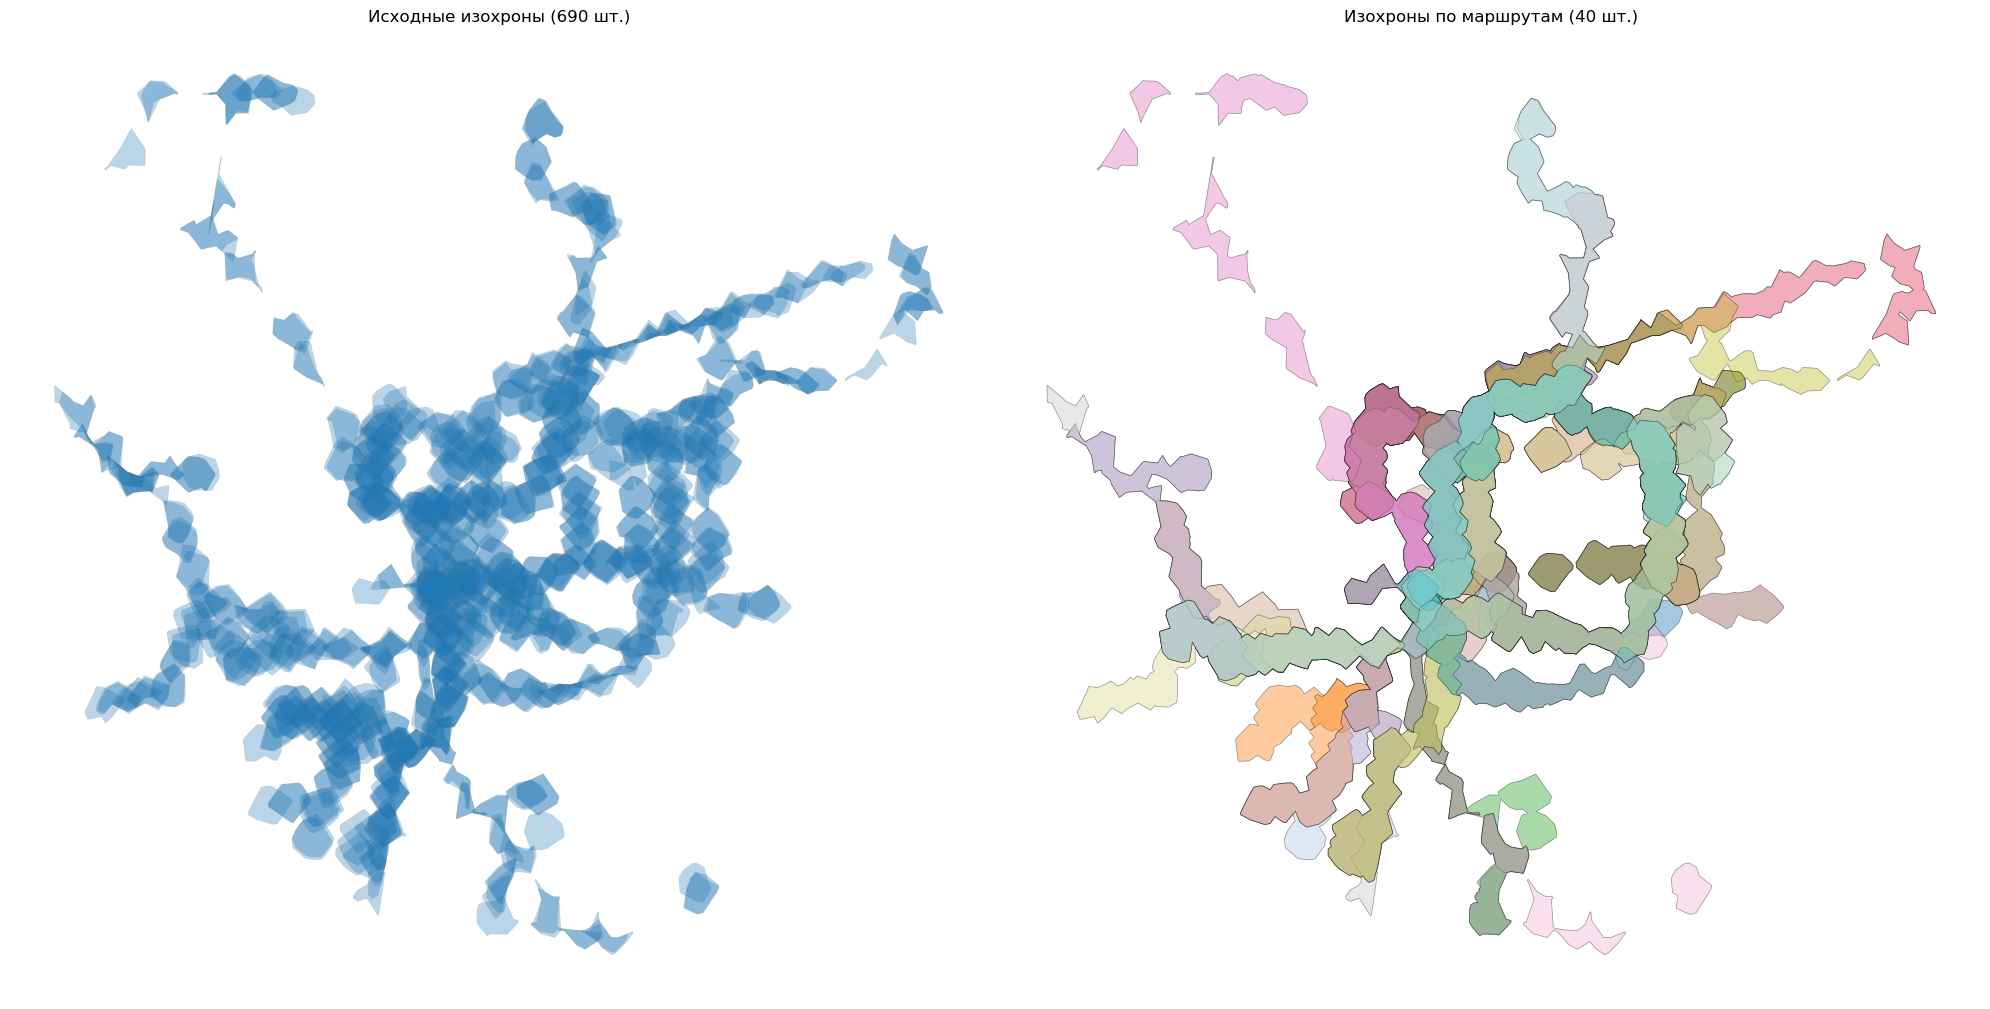

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Исходные изохроны
isochrones.plot(ax=axes[0], alpha=0.3, edgecolor='grey', linewidth=0.3)
axes[0].set_title(f"Исходные изохроны ({len(isochrones)} шт.)")

# Агрегированные по маршрутам
route_isochrones_final.plot(
    ax=axes[1], 
    column='ya_line_id', 
    alpha=0.4, 
    edgecolor='black', 
    linewidth=0.5,
    legend=False,
    cmap='tab20'
)
axes[1].set_title(f"Изохроны по маршрутам ({len(route_isochrones)} шт.)")

for ax in axes:
    ax.set_axis_off()

plt.tight_layout()
plt.show()

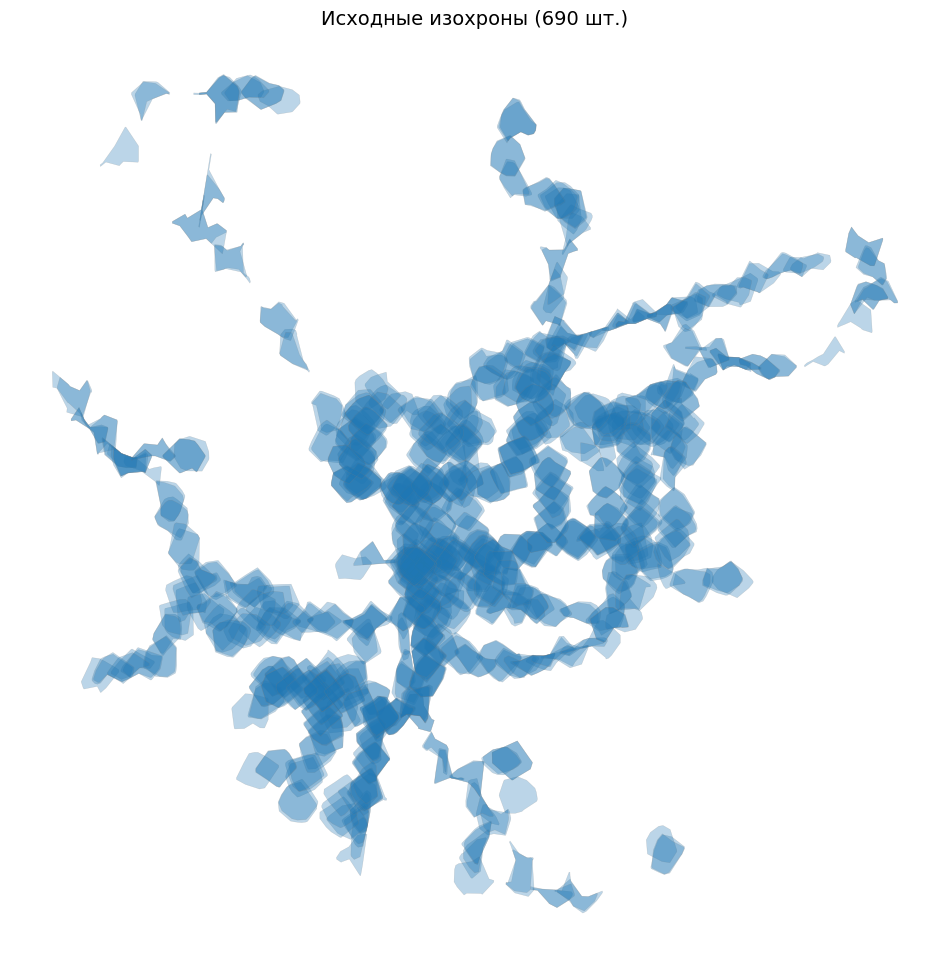

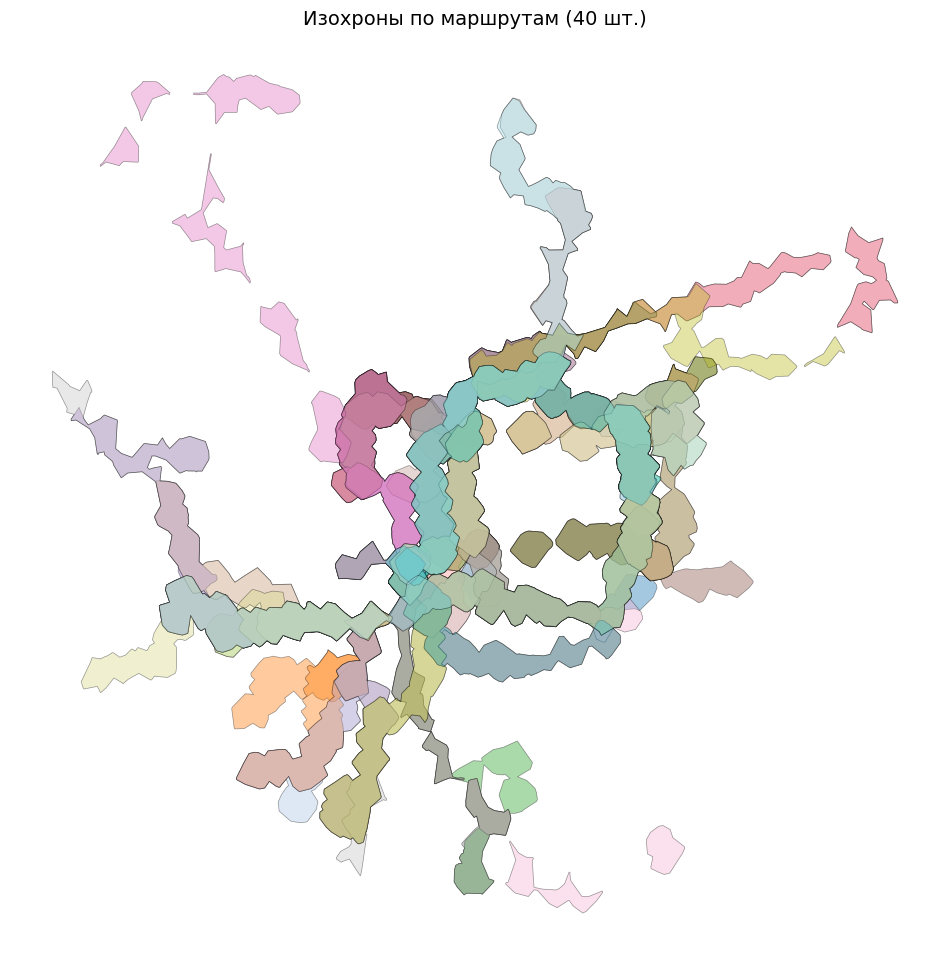

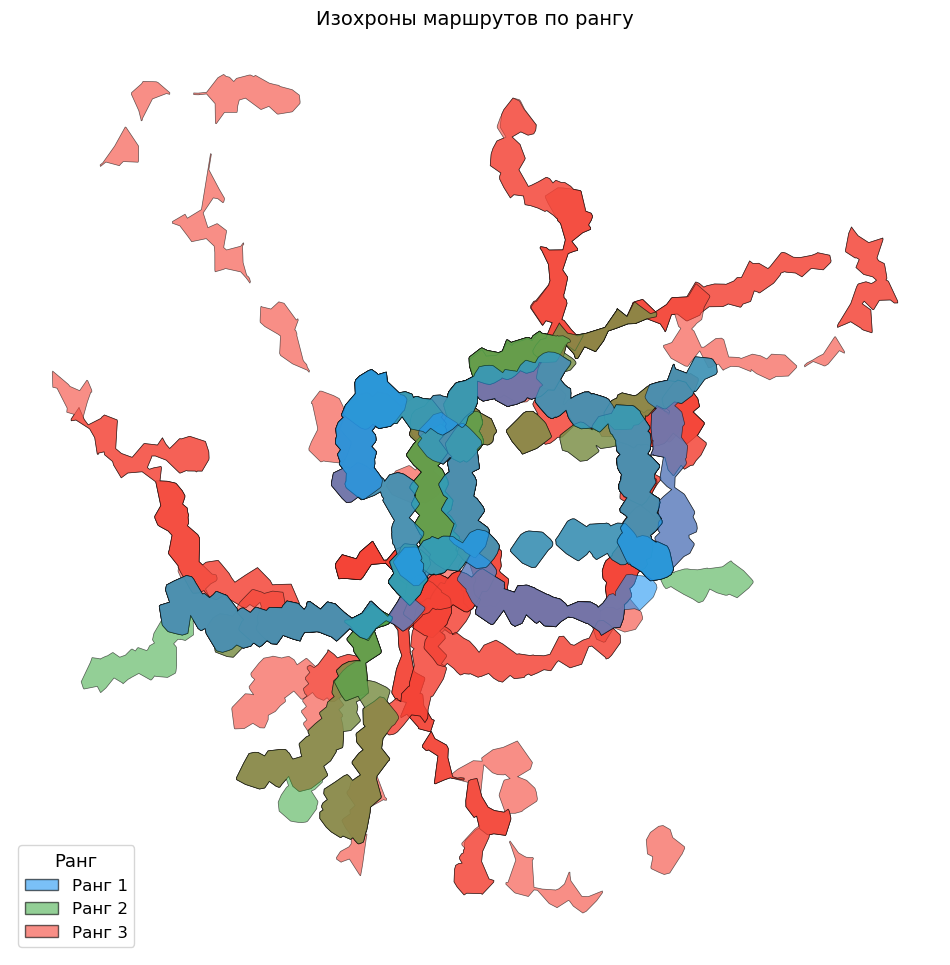

In [22]:
# Ячейка 11.1 — Визуализация: Исходные изохроны
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots(figsize=(12, 12))

isochrones.plot(ax=ax1, alpha=0.3, edgecolor='grey', linewidth=0.3)
ax1.set_title(f"Исходные изохроны ({len(isochrones)} шт.)", fontsize=14)
ax1.set_axis_off()

# Экспорт (раскомментируйте для сохранения)
# fig1.savefig("1_raw_isochrones.png", dpi=300, bbox_inches='tight')

plt.show()

# Ячейка 11.2 — Визуализация: Агрегированные по маршрутам
fig2, ax2 = plt.subplots(figsize=(12, 12))

route_isochrones_final.plot(
    ax=ax2,
    column='ya_line_id',
    alpha=0.4,
    edgecolor='black',
    linewidth=0.5,
    legend=False,
    cmap='tab20'
)
ax2.set_title(f"Изохроны по маршрутам ({len(route_isochrones_final)} шт.)", fontsize=14)
ax2.set_axis_off()

# Экспорт (раскомментируйте для сохранения)
# fig2.savefig("2_isochrones_by_route.png", dpi=300, bbox_inches='tight')

plt.show()

# Ячейка 11.3 — Визуализация: По полю rank
import matplotlib.patches as mpatches

fig3, ax3 = plt.subplots(figsize=(12, 12))

# Определяем цвета для rank
rank_colors = {
    1: '#2196F3',  # синий
    2: '#4CAF50',  # зелёный
    3: '#F44336',  # красный
}

# zorder: чем больше число, тем выше слой на графике
zorder_map = {1: 3, 2: 2, 3: 1}

# Назначаем цвет каждому полигону (временная колонка)
route_isochrones_final['_color'] = route_isochrones_final['rank'].map(rank_colors)

for rank_val, color in rank_colors.items():
    subset = route_isochrones_final[route_isochrones_final['rank'] == rank_val]
    if not subset.empty:
        subset.plot(
            ax=ax3,
            color=color,
            alpha=0.6,
            edgecolor='black',
            linewidth=0.5,
            zorder=zorder_map[rank_val]
        )

# Легенда
legend_patches = [
    mpatches.Patch(facecolor=color, edgecolor='black', alpha=0.6, label=f'Ранг {rank_val}')
    for rank_val, color in rank_colors.items()
]
ax3.legend(handles=legend_patches, loc='lower left', fontsize=12, title='Ранг', title_fontsize=13)
ax3.set_title("Изохроны маршрутов по рангу", fontsize=14)
ax3.set_axis_off()

# Убираем служебную колонку
route_isochrones_final.drop(columns='_color', inplace=True, errors='ignore')

# Экспорт (раскомментируйте для сохранения)
# fig3.savefig("3_isochrones_by_rank.png", dpi=300, bbox_inches='tight')

plt.show()